# Disease Symptom Prediction - Exploratory Data Analysis

## Project

AI Disease Prediction System

## Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the cleaned Disease Symptom Prediction dataset.

The analysis focuses on understanding:

- Dataset structure and quality
- Disease/class distribution
- Symptom frequency
- Missing symptom patterns
- Symptom count distribution
- Disease-symptom relationships
- Symptom co-occurrence patterns
- Potential data quality issues

The findings from this notebook will guide feature selection, preprocessing, and model development.

---

**Author:** Shahbaj Tanvir Shawon

**Course:** CSE Project

**Notebook:** 02_EDA.ipynb

# 1. Import Required Libraries

This section imports the Python libraries required for:

- Data manipulation
- Numerical analysis
- Data visualization
- Statistical exploration
- File and path management

In [3]:
# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# File and path handling
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Set visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Project Paths and Configuration

The processed dataset generated by `01_Data_Cleaning.ipynb` is used as the input for this EDA notebook.

EDA analysis results are stored separately from application visualization assets.

- CSV analysis results are stored in `data/processed/eda_outputs/`
- EDA visualization images are stored in `app/statics/images/eda/`
- The automated profiling report is stored in `notebooks/eda_report.html`

In [4]:
from pathlib import Path

PROJECT_ROOT = Path("../")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
EDA_OUTPUT_DIR = PROCESSED_DATA_DIR / "eda_outputs"

EDA_IMAGE_DIR = PROJECT_ROOT / "app" / "statics" / "images" / "eda"

EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = PROCESSED_DATA_DIR / "disease_clean.csv"

TARGET_COLUMN = "Disease"

print("Project configuration completed.")
print(f"Processed dataset : {DATA_FILE}")
print(f"EDA output directory : {EDA_OUTPUT_DIR}")
print(f"EDA image directory : {EDA_IMAGE_DIR}")

Project configuration completed.
Processed dataset : ..\data\processed\disease_clean.csv
EDA output directory : ..\data\processed\eda_outputs
EDA image directory : ..\app\statics\images\eda


# 3. Load Processed Dataset

The cleaned dataset generated during the data-cleaning stage is loaded for exploratory analysis.

Using the processed dataset ensures that the EDA is performed on the same data that will be used during subsequent model development.

In [5]:
# Load processed dataset
df = pd.read_csv(DATA_FILE)

print("Processed dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Processed dataset loaded successfully!
Dataset shape: (4920, 19)


# 4. Dataset Overview

Before performing detailed analysis, we inspect the basic structure of the dataset.

The following information will be examined:

- Number of observations
- Number of features
- Column names
- Data types
- Memory usage

In [6]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

DATASET OVERVIEW
Number of Rows    : 4920
Number of Columns : 19

Column Names:
['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17', 'Symptom_Count']

Data Types:
Disease          object
Symptom_1        object
Symptom_2        object
Symptom_3        object
Symptom_4        object
Symptom_5        object
Symptom_6        object
Symptom_7        object
Symptom_8        object
Symptom_9        object
Symptom_10       object
Symptom_11       object
Symptom_12       object
Symptom_13       object
Symptom_14       object
Symptom_15       object
Symptom_16       object
Symptom_17       object
Symptom_Count     int64
dtype: object


# 5. Preview the Dataset

A small sample of the dataset is displayed to verify that the processed data has been loaded correctly.

In [7]:
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17,Symptom_Count
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


# 6. Dataset Statistical Summary

The dataset primarily contains categorical symptom and disease information.

A general statistical summary is generated to understand:

- Number of unique values
- Most frequent values
- Frequency of the most common category

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Disease,4920,41,Fungal infection,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_1,4920,34,vomiting,822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_2,4920,48,vomiting,870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_3,4920,54,fatigue,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_4,4572,50,high_fever,378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_5,3714,38,headache,348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_6,2934,32,nausea,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_7,2268,26,abdominal_pain,264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_8,1944,21,abdominal_pain,276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_9,1692,22,yellowing_of_eyes,228,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 7. Missing Value Analysis

Missing values are expected in the symptom columns because a patient record does not necessarily contain all 17 possible symptom positions.

Therefore, missing values are analyzed rather than automatically removed.

We calculate:

- Number of missing values
- Percentage of missing values

In [9]:
missing_analysis = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage (%)": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_analysis = missing_analysis.sort_values(
    by="Missing Values",
    ascending=False
)

missing_analysis

,Missing Values,Missing Percentage (%)
Symptom_17,4848,98.54
Symptom_16,4728,96.10
Symptom_15,4680,95.12
Symptom_14,4614,93.78
Symptom_13,4416,89.76
Symptom_12,4176,84.88
Symptom_11,3726,75.73
Symptom_10,3408,69.27
Symptom_9,3228,65.61
Symptom_8,2976,60.49


## Missing Value Visualization

The following visualization shows the number of missing values in each column.

This helps identify whether missing values are concentrated in specific symptom columns.

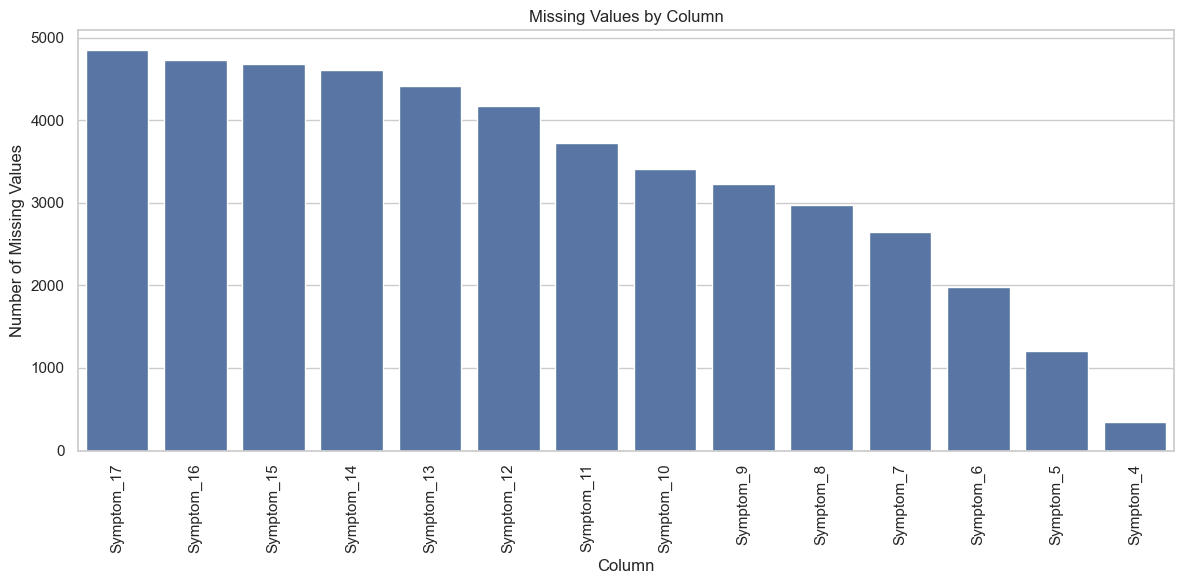

In [10]:
missing_plot = missing_analysis[
    missing_analysis["Missing Values"] > 0
]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_plot.index,
    y=missing_plot["Missing Values"]
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# 8. Target Variable Analysis

The target variable is `Disease`.

The purpose of this analysis is to determine:

- Number of unique disease classes
- Number of records per disease
- Whether the target distribution is balanced

In [11]:
# Disease class distribution
disease_counts = df[TARGET_COLUMN].value_counts()

print(f"Number of Disease Classes: {df[TARGET_COLUMN].nunique()}")

print("\nDisease Distribution:")
disease_counts

Number of Disease Classes: 41

Disease Distribution:


Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hepat

## Section 1 — Class Imbalance Analysis

Class imbalance occurs when some disease classes contain substantially more observations than others.

A significant difference between the most common and least common disease classes can cause a classification model to favor classes with more training examples.

The class distribution is therefore analyzed using the number of samples per disease, the percentage of the total dataset, and the ratio between the largest and smallest classes.

If meaningful class imbalance is observed, techniques such as class-weighted learning or resampling methods such as SMOTE may be considered during model development. The appropriate approach should ultimately be determined using training and validation results.

In [12]:
class_counts = df[TARGET_COLUMN].value_counts().sort_values(ascending=False)

most_common_class = class_counts.idxmax()
rarest_class = class_counts.idxmin()

max_samples = class_counts.max()
min_samples = class_counts.min()

imbalance_ratio = max_samples / min_samples

print("=" * 60)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)

print(f"Number of disease classes : {len(class_counts)}")
print(f"Most common disease      : {most_common_class}")
print(f"Most common samples      : {max_samples}")
print(f"Rarest disease           : {rarest_class}")
print(f"Rarest samples           : {min_samples}")
print(f"Imbalance ratio          : {imbalance_ratio:.2f}:1")

CLASS IMBALANCE ANALYSIS
Number of disease classes : 41
Most common disease      : Fungal infection
Most common samples      : 120
Rarest disease           : Fungal infection
Rarest samples           : 120
Imbalance ratio          : 1.00:1


### Interpretation

The imbalance ratio is calculated by dividing the number of observations in the largest disease class by the number of observations in the smallest disease class.

A higher ratio indicates a greater difference in class representation. This information should be considered when selecting the model training strategy and evaluation metrics.

## Target Class Balance

A multi-class classification problem should be examined for class imbalance.

A balanced target distribution means that the model is less likely to favor particular disease classes simply because they contain substantially more training examples.

In [13]:
# Calculate class distribution percentages
class_distribution = pd.DataFrame({
    "Count": disease_counts,
    "Percentage (%)": (
        disease_counts / len(df) * 100
    ).round(2)
})

class_distribution

,Count,Percentage (%)
Disease,,
Fungal infection,120,2.44
Allergy,120,2.44
GERD,120,2.44
Chronic cholestasis,120,2.44
Drug Reaction,120,2.44
Peptic ulcer diseae,120,2.44
AIDS,120,2.44
Diabetes,120,2.44
Gastroenteritis,120,2.44


## Disease Distribution Visualization

The distribution of disease classes is visualized to make differences in class frequency easier to identify.

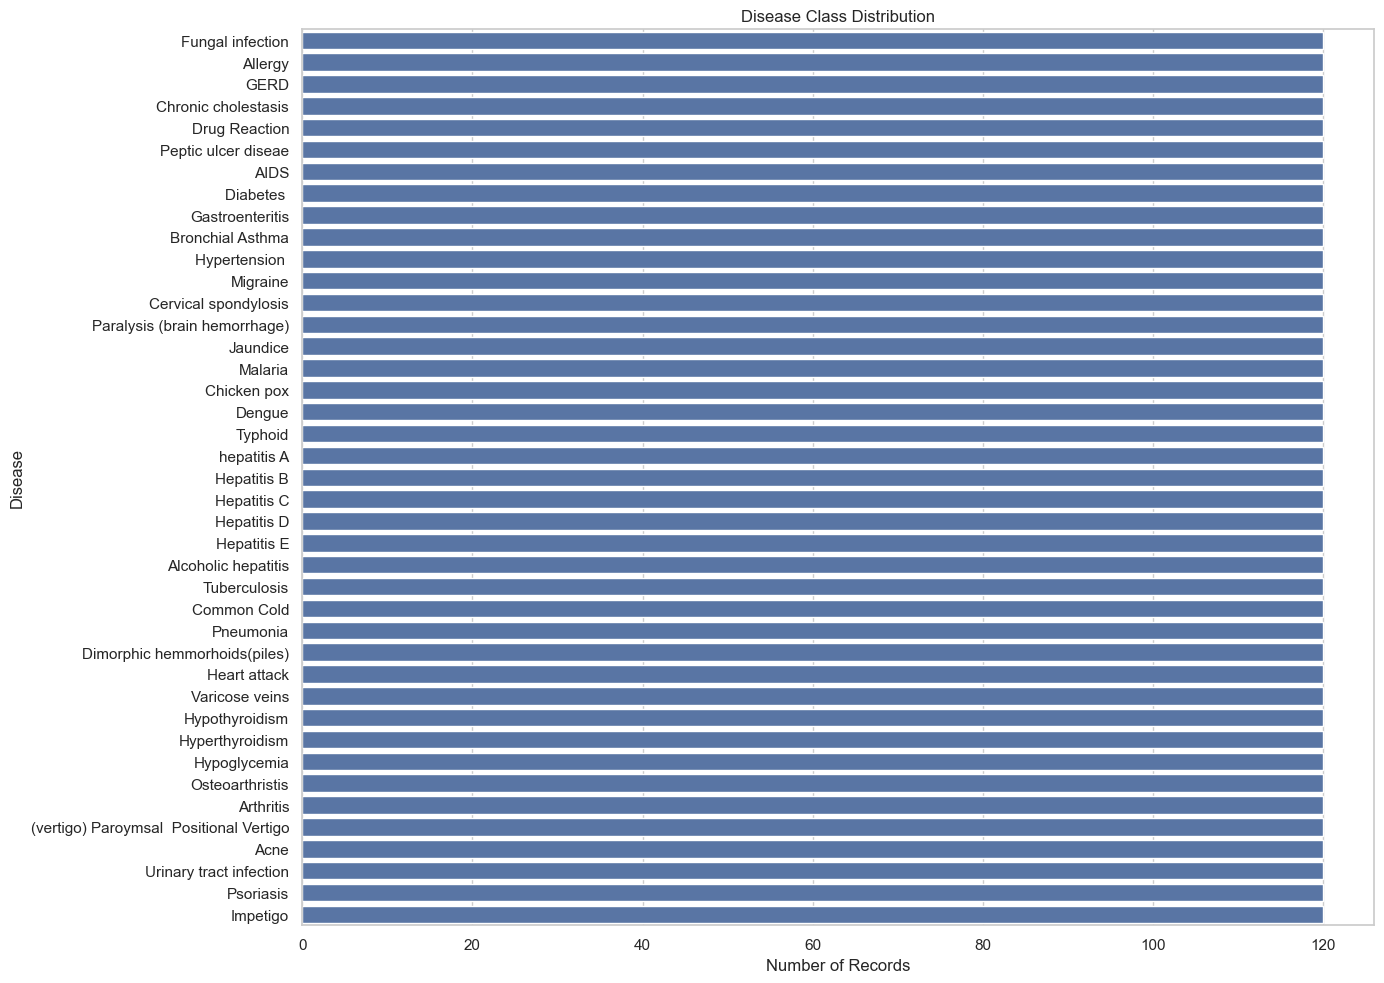

Saved: ..\app\statics\images\eda\class_distribution.png


In [14]:
plt.figure(figsize=(14, 10))

sns.barplot(
    x=class_counts.values,
    y=class_counts.index
)

plt.title("Disease Class Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Disease")

plt.tight_layout()

class_distribution_path = EDA_IMAGE_DIR / "class_distribution.png"

plt.savefig(
    class_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {class_distribution_path}")

# 9. Symptom Frequency Analysis

The symptom columns contain the symptoms associated with each disease record.

To understand the importance and frequency of individual symptoms, all symptom columns are combined into a single series.

This allows us to determine:

- Most frequently occurring symptoms
- Least frequently occurring symptoms
- Overall symptom distribution

In [15]:
# Identify symptom columns
symptom_columns = [
    column for column in df.columns
    if column.startswith("Symptom_")
]

print(f"Number of symptom columns: {len(symptom_columns)}")
print("\nSymptom columns:")
print(symptom_columns)

Number of symptom columns: 18

Symptom columns:
['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17', 'Symptom_Count']


In [16]:
# Combine all symptom columns
all_symptoms = df[symptom_columns].stack().dropna()

# Count symptom frequency
symptom_frequency = all_symptoms.value_counts()

print(f"Unique symptoms found: {symptom_frequency.nunique()}")
print("\nTop 20 Most Frequent Symptoms:")

symptom_frequency.head(20)

Unique symptoms found: 45

Top 20 Most Frequent Symptoms:


fatigue              1932
vomiting             1914
high_fever           1362
loss_of_appetite     1152
nausea               1146
headache             1134
abdominal_pain       1032
yellowish_skin        912
4                     858
yellowing_of_eyes     816
chills                798
skin_rash             786
5                     780
malaise               702
chest_pain            696
joint_pain            684
itching               678
sweating              678
6                     666
dark_urine            570
Name: count, dtype: int64

## Top Symptoms Visualization

The most frequently occurring symptoms are visualized to identify the symptoms that appear most often across the dataset.

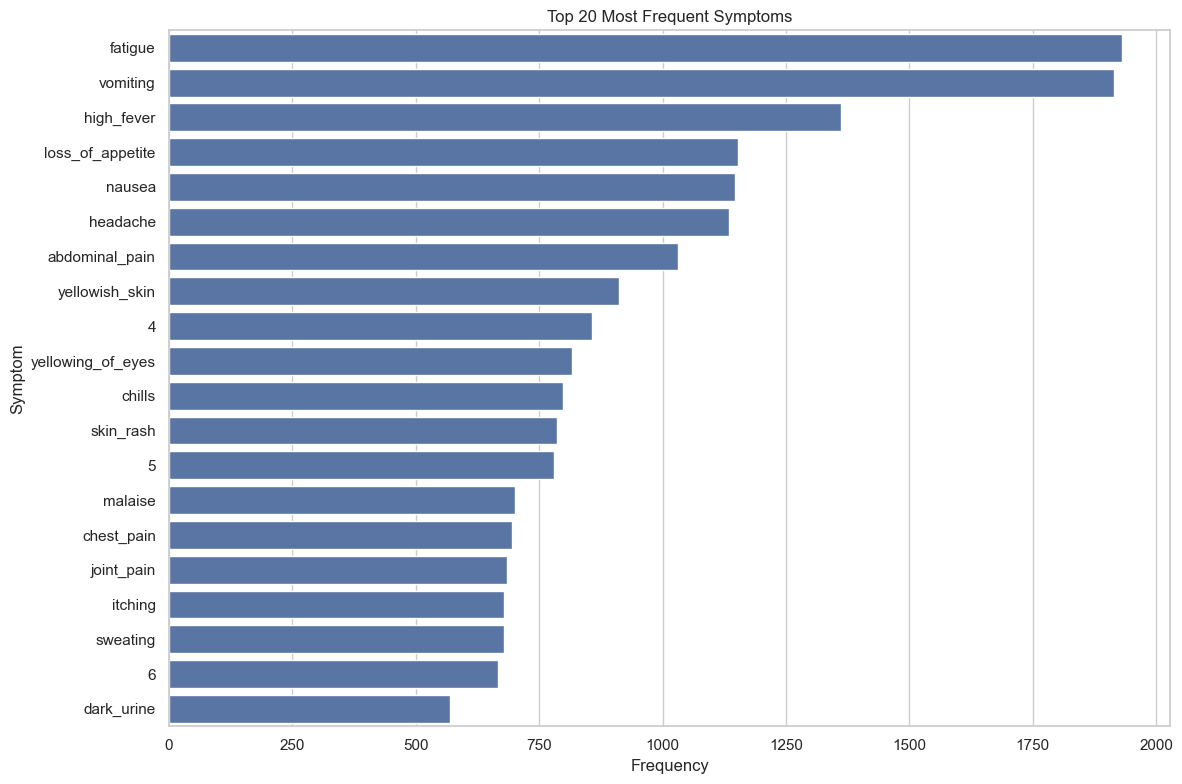

In [17]:
top_symptoms = symptom_frequency.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_symptoms.values,
    y=top_symptoms.index
)

plt.title("Top 20 Most Frequent Symptoms")
plt.xlabel("Frequency")
plt.ylabel("Symptom")

plt.tight_layout()
plt.show()

# 10. Symptom Count Analysis

`Symptom_Count` was created during the data-cleaning and feature-engineering stage.

It represents the total number of reported symptoms for each record.

Analyzing this feature helps us understand the distribution of symptom burden across the dataset.

In [18]:
df["Symptom_Count"].describe()

count    4920.000000
mean        7.448780
std         3.592166
min         3.000000
25%         5.000000
50%         6.000000
75%        10.000000
max        17.000000
Name: Symptom_Count, dtype: float64

## Numerical Feature Analysis

Numerical features are analyzed to understand their distribution, central tendency, spread, and potential outliers.

The processed dataset currently contains `Symptom_Count` as a numerical feature. It represents the total number of reported symptoms associated with each record.

In [19]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical features:")
for feature in numeric_features:
    print("-", feature)

print(f"\nNumber of numerical features: {len(numeric_features)}")

Numerical features:
- Symptom_Count

Number of numerical features: 1


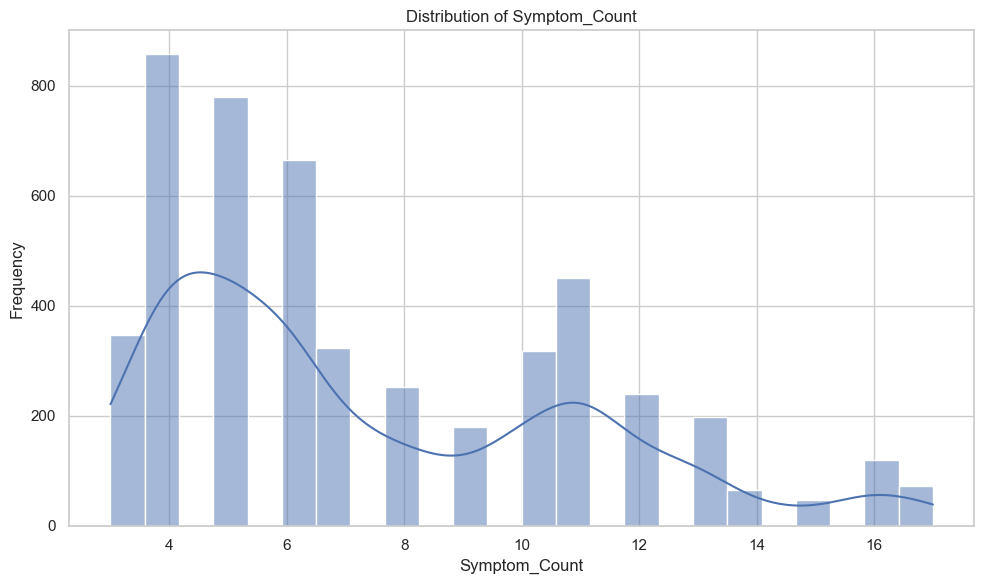

Saved: ..\app\statics\images\eda\symptom_count_distribution.png


In [20]:
for feature in numeric_features:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()

    output_path = EDA_IMAGE_DIR / f"{feature.lower()}_distribution.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")

## Numerical Feature Statistics

Descriptive statistics are used to examine the central tendency and spread of numerical features.

The analysis includes:

- Count
- Mean
- Standard deviation
- Minimum
- Quartiles
- Maximum

In [21]:
numerical_summary = df[numeric_features].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Symptom_Count,4920.0,7.44878,3.592166,3.0,5.0,6.0,10.0,17.0


## Outlier Analysis

Boxplots are used to identify observations that fall outside the typical range of a numerical feature.

Potential outliers are identified using the Interquartile Range (IQR) method.

An observation identified as a potential outlier is not automatically considered an error. It may represent a valid observation and therefore should be investigated before removal.

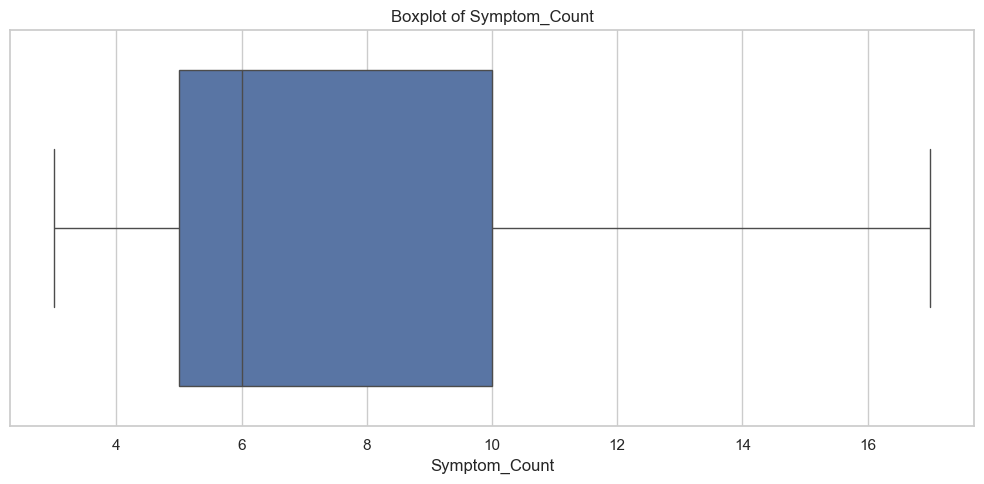

Saved: ..\app\statics\images\eda\symptom_count_boxplot.png


In [22]:
for feature in numeric_features:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()

    output_path = EDA_IMAGE_DIR / f"{feature.lower()}_boxplot.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")

### Potential Outlier Summary

The Interquartile Range (IQR) is used to identify potential outliers.

The IQR is calculated from the first quartile (Q1) and third quartile (Q3).

Potential outliers are observations below the lower IQR boundary or above the upper IQR boundary.

In [23]:
outlier_summary = []

for feature in numeric_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,Symptom_Count,5.0,10.0,5.0,-2.5,17.5,0


In [24]:
numerical_summary.to_csv(
    EDA_OUTPUT_DIR / "numerical_feature_summary.csv"
)

outlier_summary.to_csv(
    EDA_OUTPUT_DIR / "outlier_summary.csv",
    index=False
)

print("Numerical and outlier analysis results saved successfully.")

Numerical and outlier analysis results saved successfully.


# 11. Symptom Correlation Analysis

The original symptom columns contain categorical symptom names rather than numerical measurements.

Therefore, arbitrary numerical encoding of symptom names is not appropriate for correlation analysis.

Instead, each unique symptom will be represented as a binary feature:

- `1` = symptom is present in the record
- `0` = symptom is absent

This binary representation allows exploratory analysis of relationships between symptom occurrences.

In [25]:
symptom_columns = [
    column for column in df.columns
    if column.startswith("Symptom_")
    and column != "Symptom_Count"
]

print("Symptom columns:")
for column in symptom_columns:
    print("-", column)

print(f"\nNumber of symptom columns: {len(symptom_columns)}")

Symptom columns:
- Symptom_1
- Symptom_2
- Symptom_3
- Symptom_4
- Symptom_5
- Symptom_6
- Symptom_7
- Symptom_8
- Symptom_9
- Symptom_10
- Symptom_11
- Symptom_12
- Symptom_13
- Symptom_14
- Symptom_15
- Symptom_16
- Symptom_17

Number of symptom columns: 17


## Binary Symptom-Presence Matrix

Each unique symptom is converted into a binary feature.

For every record:

- `1` indicates that the symptom appears in the record.
- `0` indicates that the symptom does not appear in the record.

This representation is used only for exploratory correlation analysis and does not replace the original symptom features used for model training.

In [26]:
symptom_long = (
    df[symptom_columns]
    .stack()
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
)

unique_symptoms = sorted(symptom_long.unique())

symptom_presence = pd.DataFrame(
    0,
    index=df.index,
    columns=unique_symptoms
)

for index, row in df[symptom_columns].iterrows():

    symptoms = (
        row.dropna()
        .astype(str)
        .str.strip()
        .str.lower()
        .unique()
    )

    symptom_presence.loc[index, symptoms] = 1

print("Symptom presence matrix created successfully.")
print(f"Records : {symptom_presence.shape[0]}")
print(f"Symptoms: {symptom_presence.shape[1]}")

Symptom presence matrix created successfully.
Records : 4920
Symptoms: 131


In [27]:
unique_values = pd.unique(symptom_presence.values.ravel())

print("Unique values in symptom presence matrix:")
print(unique_values)

print("\nMatrix shape:")
print(symptom_presence.shape)

Unique values in symptom presence matrix:
[0 1]

Matrix shape:
(4920, 131)


## Frequently Occurring Symptoms

To maintain readability, the correlation heatmap focuses on the most frequently occurring symptoms in the dataset.

The most frequent symptoms are selected based on their total number of records in the binary symptom-presence matrix.

In [28]:
symptom_frequency_binary = symptom_presence.sum().sort_values(
    ascending=False
)

top_symptoms = symptom_frequency_binary.head(20).index

top_symptom_presence = symptom_presence[top_symptoms]

print("Top symptoms selected for correlation analysis:")

for symptom in top_symptoms:
    print(
        f"{symptom}: "
        f"{symptom_frequency_binary[symptom]} records"
    )

Top symptoms selected for correlation analysis:
fatigue: 1932 records
vomiting: 1914 records
high_fever: 1362 records
loss_of_appetite: 1152 records
nausea: 1146 records
headache: 1134 records
abdominal_pain: 1032 records
yellowish_skin: 912 records
yellowing_of_eyes: 816 records
chills: 798 records
skin_rash: 786 records
malaise: 702 records
chest_pain: 696 records
joint_pain: 684 records
itching: 678 records
sweating: 678 records
dark_urine: 570 records
cough: 564 records
diarrhoea: 564 records
irritability: 474 records


## Symptom Correlation Matrix

Pearson correlation is calculated between binary symptom-presence variables to explore statistical associations between symptoms.

A positive correlation indicates that two symptoms tend to occur together more frequently, while a negative correlation indicates that their occurrences tend to differ.

Correlation represents association and does not imply causation.

In [29]:
correlation_matrix = top_symptom_presence.corr()

correlation_matrix

,fatigue,vomiting,high_fever,loss_of_appetite,nausea,headache,abdominal_pain,yellowish_skin,yellowing_of_eyes,chills,skin_rash,malaise,chest_pain,joint_pain,itching,sweating,dark_urine,cough,diarrhoea,irritability
fatigue,1.000000,0.008883,0.412236,0.316115,0.206760,0.105446,0.150020,0.194795,0.259123,0.269437,-0.105248,0.464503,0.082038,0.066652,0.069744,0.200149,0.270713,0.259362,0.000688,0.211401
vomiting,0.008883,1.000000,0.115678,0.314888,0.524884,0.198823,0.479768,0.314570,0.269629,0.144263,-0.225046,-0.060906,0.056511,0.199921,-0.057763,0.188971,0.273884,-0.012314,0.262498,-0.099468
high_fever,0.412236,0.115678,1.000000,0.140628,0.136220,0.256798,0.056136,-0.042631,0.002574,0.541093,0.117059,0.464547,0.194646,0.034990,0.037309,0.179639,0.082617,0.384806,0.085366,-0.202018
loss_of_appetite,0.316115,0.314888,0.140628,1.000000,0.451555,-0.042763,0.486136,0.544035,0.767724,0.053581,0.049731,0.408448,-0.059175,0.393783,0.230103,-0.062314,0.456710,-0.027207,-0.036247,-0.180541
nausea,0.206760,0.524884,0.136220,0.451555,1.000000,0.328668,0.360952,0.405336,0.460140,0.195825,-0.090663,-0.068074,-0.223684,0.387319,-0.069644,0.081015,0.287309,-0.198284,0.281688,0.005855
headache,0.105446,0.198823,0.256798,-0.042763,0.328668,1.000000,-0.153940,-0.261066,-0.244038,0.340490,0.053792,0.240375,0.068661,-0.060895,-0.067585,0.083629,-0.198111,-0.033320,0.121200,0.184419
abdominal_pain,0.150020,0.479768,0.056136,0.486136,0.360952,-0.153940,1.000000,0.733180,0.527264,-0.072298,-0.224648,-0.047459,-0.209131,0.269152,0.263282,-0.205971,0.665177,-0.185384,0.153095,-0.168221
yellowish_skin,0.194795,0.314570,-0.042631,0.544035,0.405336,-0.261066,0.733180,1.000000,0.715405,-0.209885,-0.207998,-0.024117,-0.193632,0.298144,0.300936,-0.190705,0.709828,-0.171644,0.005670,-0.155754
yellowing_of_eyes,0.259123,0.269629,0.002574,0.767724,0.460140,-0.244038,0.527264,0.715405,1.000000,-0.027204,-0.194432,0.193068,0.007159,0.351520,0.173673,0.002459,0.606917,0.035092,0.035092,-0.145595
chills,0.269437,0.144263,0.541093,0.053581,0.195825,0.340490,-0.072298,-0.209885,-0.027204,1.000000,-0.029324,0.510998,0.362486,-0.004688,-0.175905,0.342364,-0.159272,0.402430,0.215512,-0.143665


## Symptom Correlation Heatmap

The correlation heatmap provides a visual representation of the relationships between frequently occurring symptoms.

The visualization is intended for exploratory analysis and does not establish causal relationships between symptoms.

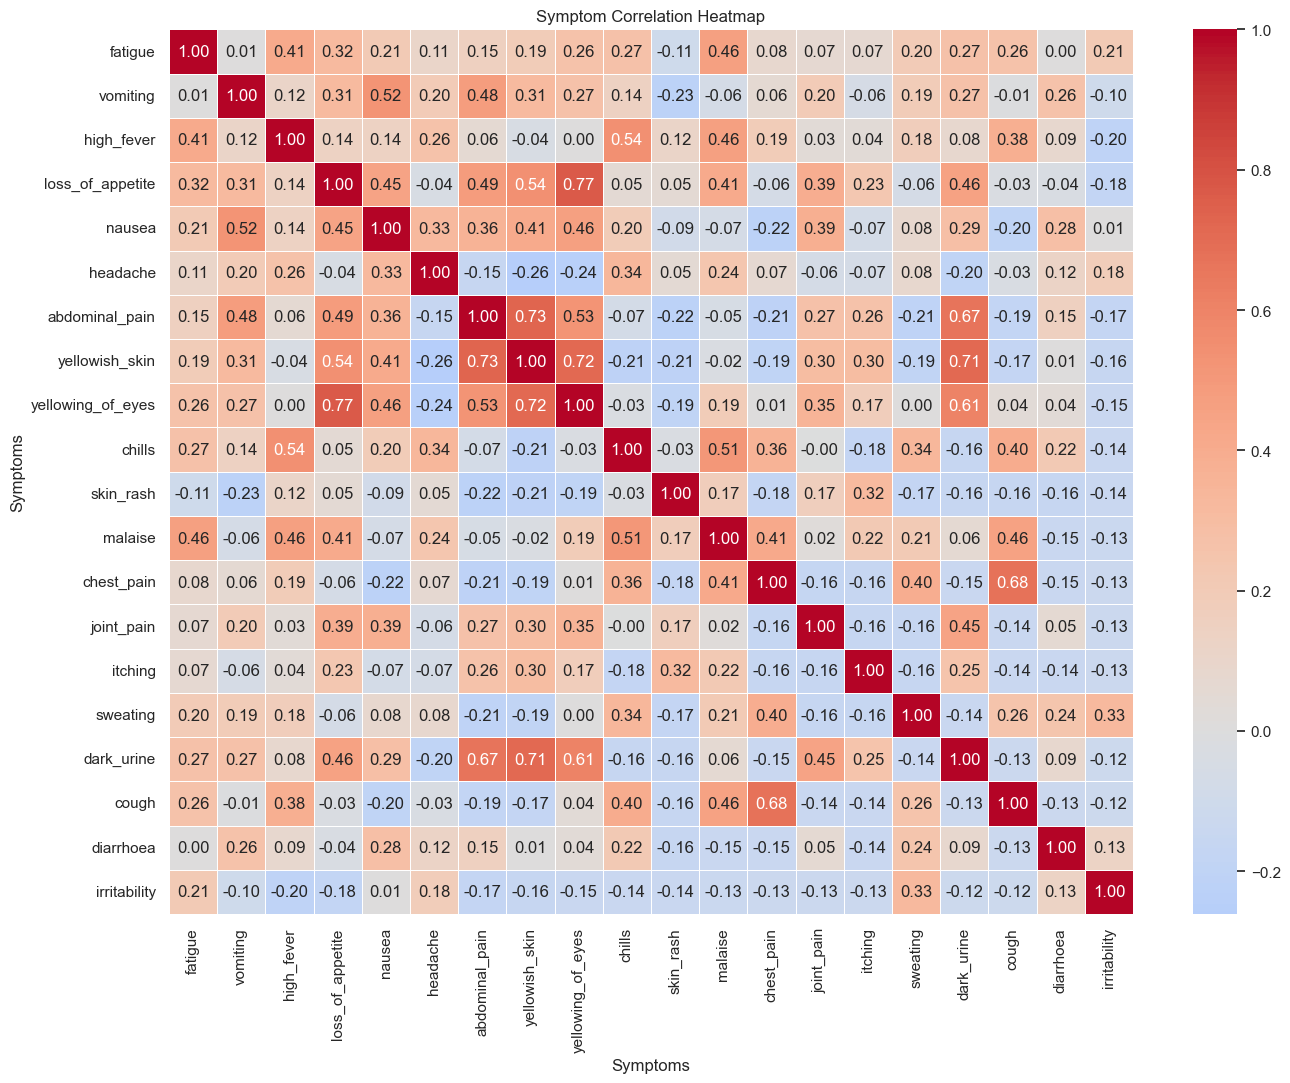

Saved: ..\app\statics\images\eda\symptom_correlation_heatmap.png


In [30]:
plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Symptom Correlation Heatmap")
plt.xlabel("Symptoms")
plt.ylabel("Symptoms")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

correlation_path = EDA_IMAGE_DIR / "symptom_correlation_heatmap.png"

plt.savefig(
    correlation_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {correlation_path}")

## Save Correlation Results

The symptom correlation matrix is saved as a CSV file so that it can be reused for documentation, further analysis, or future project development.

In [31]:
correlation_matrix.to_csv(
    EDA_OUTPUT_DIR / "symptom_correlation_matrix.csv"
)

print(
    "Saved:",
    EDA_OUTPUT_DIR / "symptom_correlation_matrix.csv"
)

Saved: ..\data\processed\eda_outputs\symptom_correlation_matrix.csv


# 12. Bias Analysis and Dataset Limitations

## Demographic Information

The disease-symptom dataset contains disease labels and symptom-related features but does not provide demographic attributes such as age, gender, ethnicity, socioeconomic status, or geographic information.

Therefore, demographic subgroup performance cannot be directly evaluated using this dataset.

## Representation Limitation

Because demographic information is unavailable, it is not possible to determine whether the model performs consistently across different demographic groups.

This limitation should be considered when interpreting the model's real-world applicability.

## Duplicate Records

The dataset contains a large number of duplicate records. These records were retained during the data-cleaning stage.

Repeated observations may influence model evaluation if identical or highly similar records appear in both training and testing datasets. Therefore, duplicate-aware evaluation should be considered during model development.

## Clinical Limitation

The dataset represents a symptom-to-disease classification problem. The resulting model should therefore be treated as an educational or experimental prediction system rather than a replacement for professional medical diagnosis.

Model predictions should not be interpreted as confirmed medical diagnoses.

# 13. Automated EDA Report

An automated exploratory data analysis report is generated using `ydata-profiling`.

The report provides an additional automated overview of dataset structure, variable types, missing values, distributions, duplicates, and statistical relationships.

In [33]:
from ydata_profiling import ProfileReport

profile_report = ProfileReport(
    df,
    title="AI Disease Prediction - EDA Report",
    explorative=True
)

REPORT_PATH = PROJECT_ROOT / "notebooks" / "eda_report.html"

profile_report.to_file(REPORT_PATH)

print(f"EDA profiling report saved to: {REPORT_PATH}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:00<00:00, 57.82it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

EDA profiling report saved to: ..\notebooks\eda_report.html


# 14. Week 2 EDA Summary

The second-stage exploratory data analysis provided a more detailed understanding of the disease-symptom dataset.

### Class Distribution

The dataset contains multiple disease classes with different numbers of observations. The class imbalance ratio was calculated to identify differences in class representation.

### Numerical Feature Distribution

The `Symptom_Count` feature was analyzed using descriptive statistics, distribution plots, and boxplots.

### Outlier Analysis

The IQR method was used to identify potential outliers in numerical features. Potential outliers were not automatically removed because an unusual observation is not necessarily an erroneous observation.

### Symptom Correlation

A binary symptom-presence representation was created to explore relationships between frequently occurring symptoms. A correlation matrix and heatmap were generated for exploratory analysis.

### Bias and Dataset Limitations

The dataset does not contain demographic information, so demographic subgroup performance cannot be evaluated directly. The presence of duplicate records is another important consideration for model evaluation.

### Automated EDA

An automated profiling report was generated using `ydata-profiling` and saved as an HTML file.

### Modeling Implications

The findings from this analysis will be considered during:

- Feature preprocessing
- Class imbalance handling
- Train/test splitting
- Model training
- Model evaluation
- Model interpretation

In [34]:
print("=" * 60)
print("WEEK 2 EDA VERIFICATION")
print("=" * 60)

print(f"Dataset shape       : {df.shape}")
print(f"Disease classes     : {df[TARGET_COLUMN].nunique()}")
print(f"Numerical features  : {numeric_features}")
print(f"Duplicate rows      : {df.duplicated().sum()}")

print("\nEDA IMAGE FILES:")

for file in sorted(EDA_IMAGE_DIR.glob("*.png")):
    print(f"✓ {file.name}")

print("\nEDA CSV OUTPUT FILES:")

for file in sorted(EDA_OUTPUT_DIR.glob("*.csv")):
    print(f"✓ {file.name}")

print("\nEDA REPORT:")

if REPORT_PATH.exists():
    print(f"✓ {REPORT_PATH.name}")
else:
    print("✗ EDA report not found")

print("\n✓ WEEK 2 EDA VERIFICATION COMPLETED")

WEEK 2 EDA VERIFICATION
Dataset shape       : (4920, 19)
Disease classes     : 41
Numerical features  : ['Symptom_Count']
Duplicate rows      : 4616

EDA IMAGE FILES:
✓ class_distribution.png
✓ symptom_correlation_heatmap.png
✓ symptom_count_boxplot.png
✓ symptom_count_distribution.png

EDA CSV OUTPUT FILES:
✓ disease_class_distribution.csv
✓ disease_symptom_matrix.csv
✓ missing_value_analysis.csv
✓ numerical_feature_summary.csv
✓ outlier_summary.csv
✓ symptom_cooccurrence.csv
✓ symptom_correlation_matrix.csv
✓ symptom_count_by_disease.csv
✓ symptom_frequency.csv

EDA REPORT:
✓ eda_report.html

✓ WEEK 2 EDA VERIFICATION COMPLETED


# 15. Additional Disease-Symptom Analysis

This section performs additional analysis to understand the relationships between diseases and their associated symptoms.

The analysis includes:

- Symptom count by disease
- Symptom co-occurrence analysis
- Disease-symptom frequency matrix
- Disease-symptom frequency heatmap

These analyses provide additional domain-oriented insights that can support feature understanding and future machine learning development.

## 15.1 Symptom Count by Disease

Different diseases may be associated with different numbers of reported symptoms.

The average, median, minimum, and maximum symptom counts are calculated for each disease class.

This analysis helps identify differences in symptom burden across disease categories.

In [35]:
symptom_count_by_disease = (
    df.groupby(TARGET_COLUMN)["Symptom_Count"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

symptom_count_by_disease

,mean,median,min,max
Disease,,,,
Common Cold,16.60,17.0,16,17
Tuberculosis,15.60,16.0,15,16
Dengue,13.55,14.0,13,14
Hepatitis E,12.60,13.0,12,13
Hypothyroidism,12.60,13.0,12,13
Hypoglycemia,11.60,12.0,11,12
Hepatitis B,11.60,12.0,11,12
Hyperthyroidism,10.60,11.0,10,11
Pneumonia,10.60,11.0,10,11


## Average Symptom Count by Disease

The following visualization shows the average number of symptoms associated with each disease class.

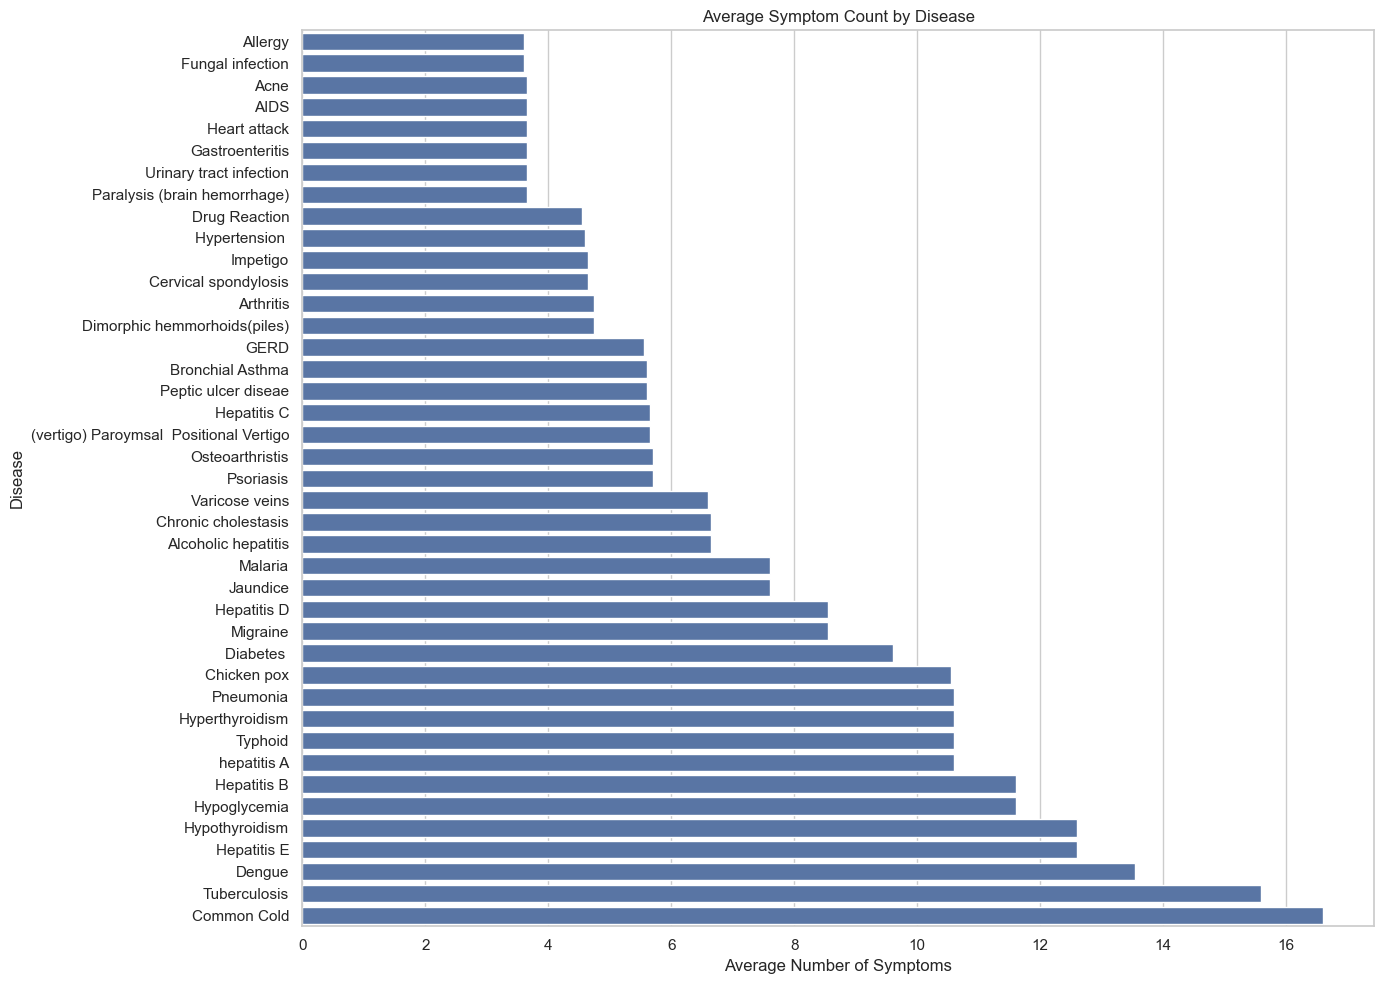

Saved: ..\app\statics\images\eda\average_symptom_count_by_disease.png


In [36]:
mean_symptoms = (
    df.groupby(TARGET_COLUMN)["Symptom_Count"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(14, 10))

sns.barplot(
    x=mean_symptoms.values,
    y=mean_symptoms.index
)

plt.title("Average Symptom Count by Disease")
plt.xlabel("Average Number of Symptoms")
plt.ylabel("Disease")

plt.tight_layout()

symptom_count_disease_path = (
    EDA_IMAGE_DIR / "average_symptom_count_by_disease.png"
)

plt.savefig(
    symptom_count_disease_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {symptom_count_disease_path}")

## 15.2 Symptom Co-occurrence Analysis

Symptoms can occur together within the same record.

This analysis identifies the most frequently occurring pairs of symptoms.

For each record, duplicate symptoms are removed before generating unique symptom pairs.

The frequency of each pair is then calculated across the dataset.

In [37]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()

for _, row in df[symptom_columns].iterrows():

    symptoms = []

    for symptom in row:
        if pd.notna(symptom):
            symptom = str(symptom).strip().lower()

            if symptom not in ["", "nan", "none"]:
                symptoms.append(symptom)

    symptoms = sorted(set(symptoms))

    for pair in combinations(symptoms, 2):
        pair_counter[pair] += 1

cooccurrence = pd.DataFrame(
    pair_counter.items(),
    columns=["Symptom_Pair", "Frequency"]
)

cooccurrence = (
    cooccurrence
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

print("Symptom co-occurrence analysis completed successfully.")
print(f"Total unique symptom pairs: {len(cooccurrence)}")

cooccurrence.head(20)

Symptom co-occurrence analysis completed successfully.
Total unique symptom pairs: 944


,Symptom_Pair,Frequency
0,"(nausea, vomiting)",978
1,"(fatigue, high_fever)",978
2,"(abdominal_pain, vomiting)",870
3,"(loss_of_appetite, yellowing_of_eyes)",786
4,"(fatigue, loss_of_appetite)",774
5,"(loss_of_appetite, vomiting)",768
6,"(abdominal_pain, yellowish_skin)",762
7,"(fatigue, vomiting)",762
8,"(fatigue, malaise)",666
9,"(loss_of_appetite, nausea)",666


## Most Common Symptom Pairs

The most frequently occurring symptom pairs are examined to identify common symptom combinations within the dataset.

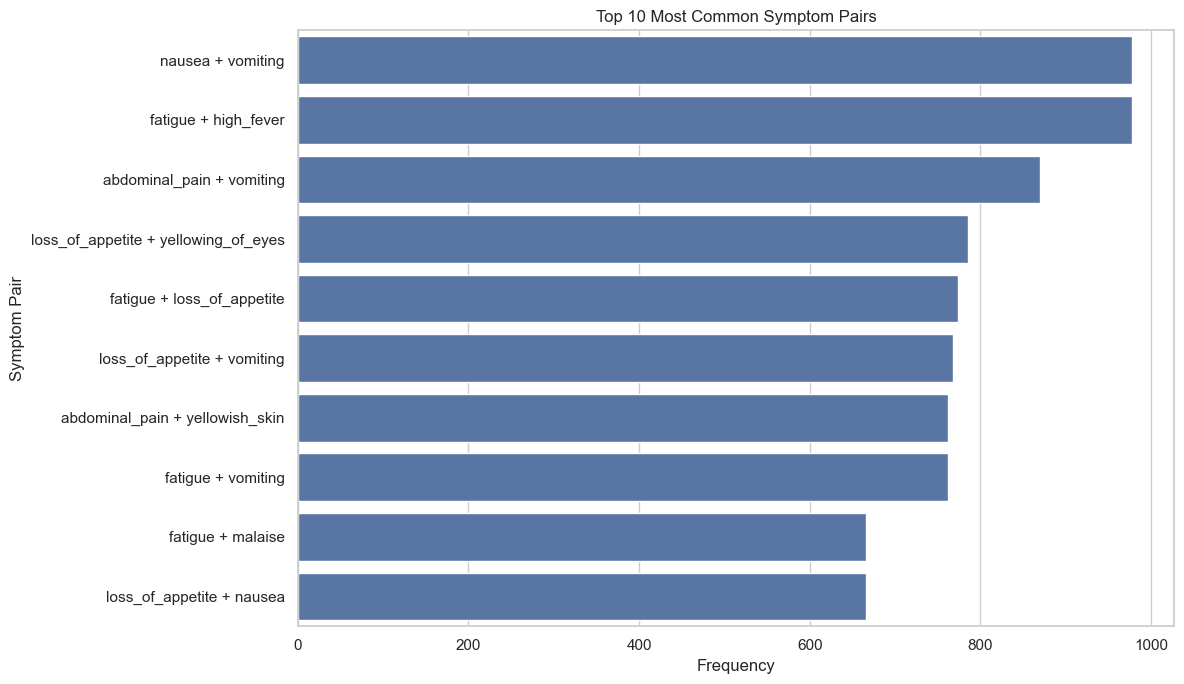

Saved: ..\app\statics\images\eda\top_symptom_cooccurrence.png


In [38]:
cooccurrence_plot = cooccurrence.copy()

cooccurrence_plot["Pair"] = cooccurrence_plot[
    "Symptom_Pair"
].apply(
    lambda x: " + ".join(x)
)

top_pairs = cooccurrence_plot.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_pairs,
    x="Frequency",
    y="Pair"
)

plt.title("Top 10 Most Common Symptom Pairs")
plt.xlabel("Frequency")
plt.ylabel("Symptom Pair")

plt.tight_layout()

cooccurrence_path = (
    EDA_IMAGE_DIR / "top_symptom_cooccurrence.png"
)

plt.savefig(
    cooccurrence_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {cooccurrence_path}")

## 15.3 Disease-Symptom Frequency Matrix

The relationship between diseases and symptoms is one of the important aspects of the dataset.

A disease-symptom frequency matrix is created where:

- Each row represents a disease.
- Each column represents a symptom.
- Each value represents the number of times a symptom appears within records belonging to that disease.

This matrix provides a structured representation of disease-symptom relationships.

In [39]:
normalized_symptoms = (
    df[symptom_columns]
    .stack()
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
)

normalized_symptoms = normalized_symptoms[
    ~normalized_symptoms.isin(["", "nan", "none"])
]

unique_symptoms = sorted(
    normalized_symptoms.unique()
)

unique_diseases = sorted(
    df[TARGET_COLUMN]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

disease_symptom_matrix = pd.DataFrame(
    0,
    index=unique_diseases,
    columns=unique_symptoms
)

for disease in unique_diseases:

    disease_data = df[
        df[TARGET_COLUMN]
        .astype(str)
        .str.strip()
        == disease
    ]

    disease_symptoms = (
        disease_data[symptom_columns]
        .stack()
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    disease_symptoms = disease_symptoms[
        ~disease_symptoms.isin(["", "nan", "none"])
    ]

    symptom_counts = disease_symptoms.value_counts()

    for symptom, count in symptom_counts.items():

        if symptom in disease_symptom_matrix.columns:
            disease_symptom_matrix.loc[
                disease, symptom
            ] = count

print("Disease-symptom frequency matrix created successfully.")

print(f"Number of diseases : {disease_symptom_matrix.shape[0]}")
print(f"Number of symptoms : {disease_symptom_matrix.shape[1]}")
print(f"Matrix shape       : {disease_symptom_matrix.shape}")

disease_symptom_matrix.head()

Disease-symptom frequency matrix created successfully.
Number of diseases : 41
Number of symptoms : 131
Matrix shape       : (41, 131)


,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,blister,blood_in_sputum,bloody_stool,blurred_and_distorted_vision,breathlessness,brittle_nails,bruising,burning_micturition,chest_pain,chills,cold_hands_and_feets,coma,congestion,constipation,continuous_feel_of_urine,continuous_sneezing,cough,cramps,dark_urine,dehydration,depression,diarrhoea,dischromic _patches,distention_of_abdomen,dizziness,drying_and_tingling_lips,enlarged_thyroid,excessive_hunger,extra_marital_contacts,family_history,fast_heart_rate,fatigue,fluid_overload,foul_smell_of urine,headache,high_fever,hip_joint_pain,history_of_alcohol_consumption,increased_appetite,indigestion,inflammatory_nails,internal_itching,irregular_sugar_level,irritability,irritation_in_anus,itching,joint_pain,knee_pain,lack_of_concentration,lethargy,loss_of_appetite,loss_of_balance,loss_of_smell,malaise,mild_fever,mood_swings,movement_stiffness,mucoid_sputum,muscle_pain,muscle_wasting,muscle_weakness,nausea,neck_pain,nodal_skin_eruptions,obesity,pain_behind_the_eyes,pain_during_bowel_movements,pain_in_anal_region,painful_walking,palpitations,passage_of_gases,patches_in_throat,phlegm,polyuria,prominent_veins_on_calf,puffy_face_and_eyes,pus_filled_pimples,receiving_blood_transfusion,receiving_unsterile_injections,red_sore_around_nose,red_spots_over_body,redness_of_eyes,restlessness,runny_nose,rusty_sputum,scurring,shivering,silver_like_dusting,sinus_pressure,skin_peeling,skin_rash,slurred_speech,small_dents_in_nails,spinning_movements,spotting_ urination,stiff_neck,stomach_bleeding,stomach_pain,sunken_eyes,sweating,swelled_lymph_nodes,swelling_joints,swelling_of_stomach,swollen_blood_vessels,swollen_extremeties,swollen_legs,throat_irritation,toxic_look_(typhos),ulcers_on_tongue,unsteadiness,visual_disturbances,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
(vertigo) Paroymsal Positional Vertigo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,114,0,0,0,0,0,0,0,0,0
AIDS,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Acne,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,108,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Alcoholic hepatitis,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,114,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,114
Allergy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0


## 15.4 Disease-Symptom Frequency Heatmap

A heatmap is used to visualize the frequency of symptoms across disease classes.

To maintain readability, the visualization focuses on the 20 most frequently occurring symptoms.

Higher values indicate that a symptom appears more frequently within records associated with a particular disease.

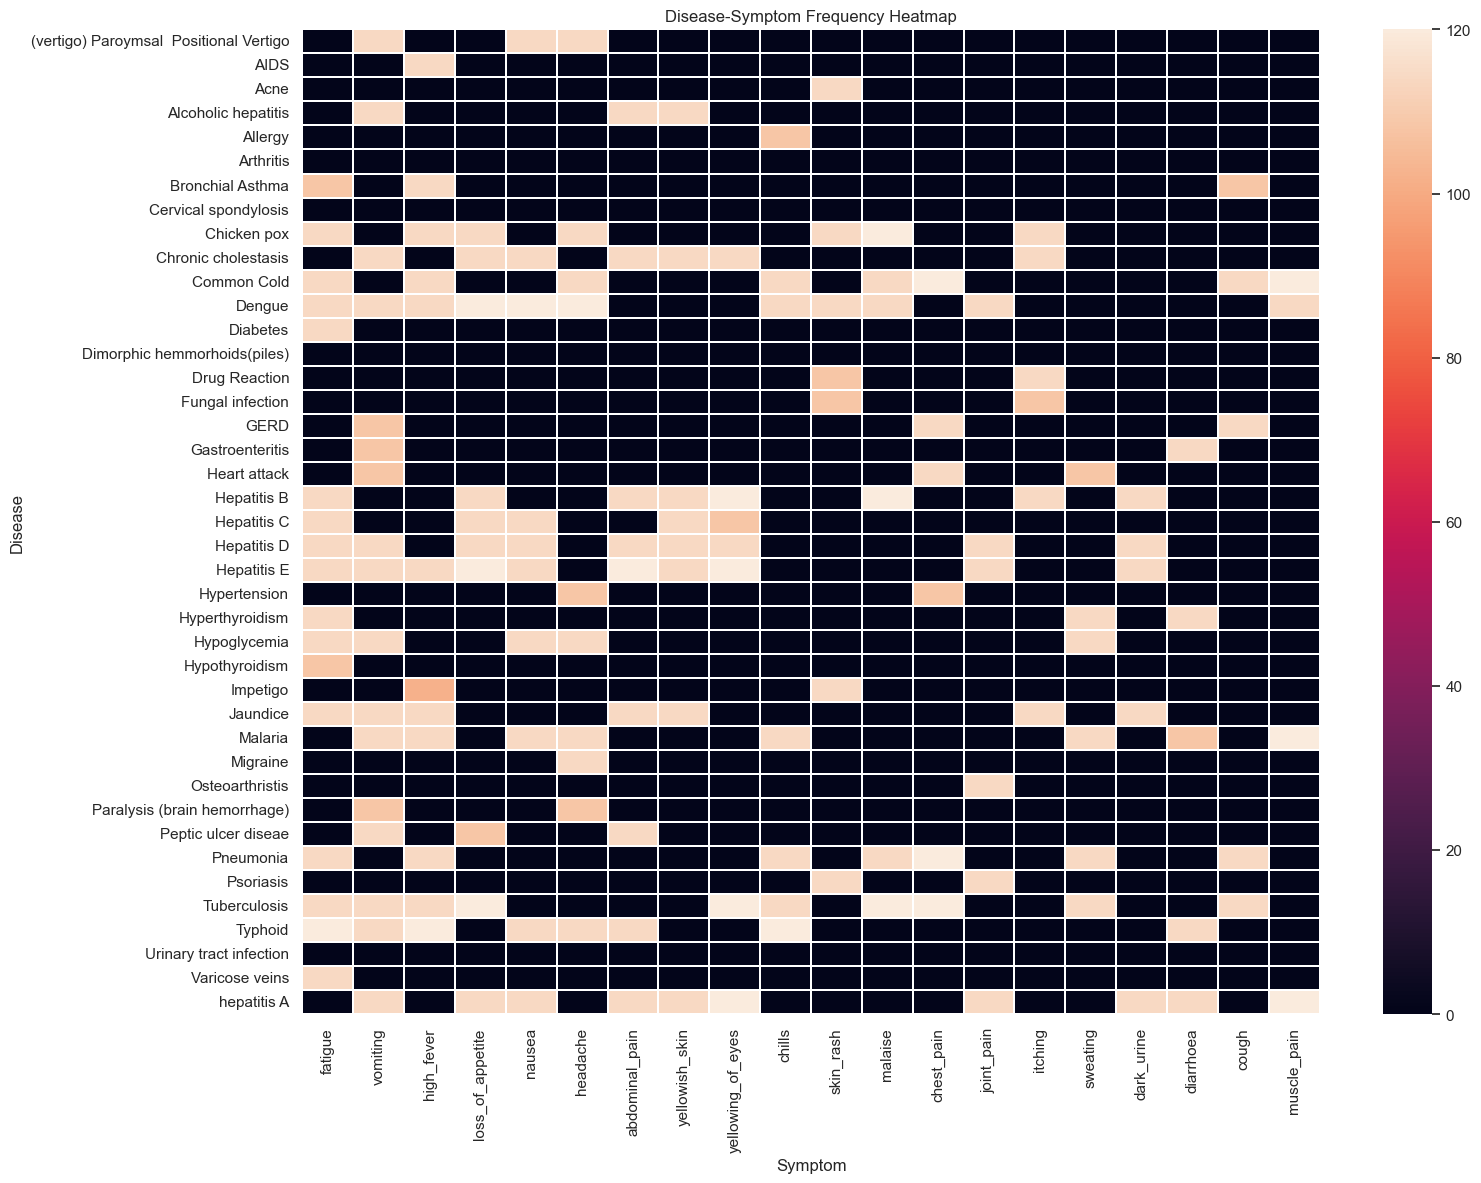

Saved: ..\app\statics\images\eda\disease_symptom_frequency_heatmap.png


In [40]:
top_20_symptoms = (
    normalized_symptoms
    .value_counts()
    .head(20)
    .index
    .tolist()
)

top_20_symptoms = [
    symptom
    for symptom in top_20_symptoms
    if symptom in disease_symptom_matrix.columns
]

heatmap_data = disease_symptom_matrix[
    top_20_symptoms
]

plt.figure(figsize=(16, 12))

sns.heatmap(
    heatmap_data,
    linewidths=0.2
)

plt.title("Disease-Symptom Frequency Heatmap")
plt.xlabel("Symptom")
plt.ylabel("Disease")
plt.xticks(rotation=90)

plt.tight_layout()

disease_symptom_heatmap_path = (
    EDA_IMAGE_DIR / "disease_symptom_frequency_heatmap.png"
)

plt.savefig(
    disease_symptom_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {disease_symptom_heatmap_path}")

# 16. Final Data Quality Checks

Before proceeding to machine learning model development, final data-quality checks are performed.

The checks verify:

- Dataset dimensions
- Number of disease classes
- Missing values in the target variable
- Duplicate records
- Number of unique symptom patterns
- Validity of the `Symptom_Count` feature
- Minimum and maximum number of reported symptoms

Duplicate records are not automatically removed because they were intentionally retained during the data-cleaning stage.

Duplicate-aware evaluation should therefore be considered during model development.

Missing values in symptom columns are expected because a record may contain fewer than 17 symptoms.

In [41]:
print("=" * 60)
print("FINAL EDA DATA QUALITY CHECK")
print("=" * 60)

print(f"Rows                  : {df.shape[0]}")
print(f"Columns               : {df.shape[1]}")
print(f"Disease Classes       : {df[TARGET_COLUMN].nunique()}")

print(
    f"Target Missing Values : "
    f"{df[TARGET_COLUMN].isnull().sum()}"
)

duplicate_rows = df.duplicated().sum()

print(
    f"Duplicate Rows        : "
    f"{duplicate_rows}"
)

eda_symptom_columns = [
    column
    for column in df.columns
    if column.startswith("Symptom_")
    and column != "Symptom_Count"
]

unique_symptom_patterns = (
    df[eda_symptom_columns]
    .fillna("__MISSING__")
    .astype(str)
    .drop_duplicates()
)

print(
    f"Unique Symptom Patterns: "
    f"{len(unique_symptom_patterns)}"
)

print(
    f"Minimum Symptom Count : "
    f"{df['Symptom_Count'].min()}"
)

print(
    f"Maximum Symptom Count : "
    f"{df['Symptom_Count'].max()}"
)

print("\n✓ Final EDA data-quality check completed.")

FINAL EDA DATA QUALITY CHECK
Rows                  : 4920
Columns               : 19
Disease Classes       : 41
Target Missing Values : 0
Duplicate Rows        : 4616
Unique Symptom Patterns: 304
Minimum Symptom Count : 3
Maximum Symptom Count : 17

✓ Final EDA data-quality check completed.


# 17. Save EDA Results

Important exploratory analysis results are saved to the `eda_outputs` directory.

These outputs can be reused for:

- Project documentation
- Final project report
- Presentation
- Further exploratory analysis
- Machine learning development

The saved results include disease distribution, missing-value analysis, symptom frequency, symptom count by disease, symptom co-occurrence, numerical analysis, outlier analysis, symptom correlation, and the disease-symptom frequency matrix.

In [42]:
# Disease class distribution
class_distribution.to_csv(
    EDA_OUTPUT_DIR / "disease_class_distribution.csv"
)

# Missing value analysis
missing_analysis.to_csv(
    EDA_OUTPUT_DIR / "missing_value_analysis.csv"
)

# Symptom frequency
symptom_frequency.to_csv(
    EDA_OUTPUT_DIR / "symptom_frequency.csv",
    header=["Frequency"]
)

# Symptom count by disease
symptom_count_by_disease.to_csv(
    EDA_OUTPUT_DIR / "symptom_count_by_disease.csv"
)

# Symptom co-occurrence
cooccurrence.to_csv(
    EDA_OUTPUT_DIR / "symptom_cooccurrence.csv",
    index=False
)

# Disease-symptom frequency matrix
disease_symptom_matrix.to_csv(
    EDA_OUTPUT_DIR / "disease_symptom_matrix.csv"
)

# Numerical feature summary
numerical_summary.to_csv(
    EDA_OUTPUT_DIR / "numerical_feature_summary.csv"
)

# Outlier summary
outlier_summary.to_csv(
    EDA_OUTPUT_DIR / "outlier_summary.csv",
    index=False
)

# Symptom correlation matrix
correlation_matrix.to_csv(
    EDA_OUTPUT_DIR / "symptom_correlation_matrix.csv"
)

print("=" * 60)
print("EDA RESULTS SAVED SUCCESSFULLY")
print("=" * 60)

print(f"Output directory: {EDA_OUTPUT_DIR}")

print("\nSaved files:")

for file in sorted(EDA_OUTPUT_DIR.glob("*.csv")):
    print(f"✓ {file.name}")

EDA RESULTS SAVED SUCCESSFULLY
Output directory: ..\data\processed\eda_outputs

Saved files:
✓ disease_class_distribution.csv
✓ disease_symptom_matrix.csv
✓ missing_value_analysis.csv
✓ numerical_feature_summary.csv
✓ outlier_summary.csv
✓ symptom_cooccurrence.csv
✓ symptom_correlation_matrix.csv
✓ symptom_count_by_disease.csv
✓ symptom_frequency.csv


# 18. Final EDA Summary & Conclusion

The exploratory data analysis provided a comprehensive understanding of the cleaned Disease Symptom Prediction dataset.

## Dataset Structure

- The dataset contains 4,920 records.
- The original dataset contains 18 columns.
- The `Symptom_Count` feature was added during feature engineering, resulting in 19 columns.

## Target Variable

- `Disease` is the target variable.
- The dataset contains 41 disease classes.
- Disease frequency was analyzed to evaluate class distribution and imbalance.

## Missing Values

- Missing values are primarily associated with symptom columns.
- These missing entries represent symptom positions that were not recorded for a particular record.
- They should not automatically be considered erroneous observations.

## Symptom Distribution

- Symptoms occur with different frequencies throughout the dataset.
- Frequently occurring symptoms may provide useful predictive information.

## Symptom Count

- `Symptom_Count` represents the total number of reported symptoms for each record.
- Its distribution and potential outliers were analyzed.

## Symptom Correlation

- A binary symptom-presence representation was created.
- Correlations between frequently occurring symptoms were explored.
- Correlation represents association and does not imply causation.

## Disease-Symptom Relationships

- Symptom count was analyzed across disease classes.
- Symptom co-occurrence patterns were identified.
- A disease-symptom frequency matrix and heatmap were generated.

## Bias and Dataset Limitations

- The dataset does not contain demographic information such as age, gender, ethnicity, socioeconomic status, or geographic information.
- Therefore, demographic subgroup performance cannot be directly evaluated.
- The dataset contains a large number of duplicate records.
- Duplicate-aware evaluation should be considered during model development.

## Clinical Limitation

The dataset represents a symptom-to-disease classification problem.

Therefore, the resulting system should be treated as an educational or experimental prediction system rather than a replacement for professional medical diagnosis.

Model predictions should not be interpreted as confirmed medical diagnoses.

## Modeling Implications

The EDA findings will guide the machine learning stage, including:

- Feature representation
- Categorical feature encoding
- Training and testing strategy
- Class-balance considerations
- Model selection
- Model evaluation
- Model interpretability

Overall, the EDA stage provides the foundation for the preprocessing and machine learning pipeline in the next stage of the project.

# 19. Next Stage: Model Development

The next stage of the project will focus on developing and evaluating machine learning models for disease prediction.

The model-development stage will include:

1. Preparing the feature matrix and target variable
2. Encoding categorical symptom features
3. Creating training and testing datasets
4. Handling class imbalance where appropriate
5. Building machine learning pipelines
6. Training multiple classification models
7. Performing cross-validation
8. Comparing model performance using appropriate evaluation metrics
9. Evaluating the selected model
10. Interpreting model predictions
11. Saving the trained model pipeline
12. Preparing the model for future API and application integration

The findings from this EDA notebook will be used to guide preprocessing, feature representation, model training, and evaluation.